# Mean Shift Clustering: Window Size (Bandwidth), KDE, and Scikit-learn

Topics covered in this notebook:

1. Kernel Density Estimation (KDE) in 1D: the idea behind mean shift
2. Mean shift from scratch (1D, then 2D) to see the window sliding uphill
3. Mean shift with `sklearn.cluster.MeanShift`
4. Choosing the bandwidth (window size) with `estimate_bandwidth`
5. Effect of bandwidth on the number of clusters
6. `bin_seeding` and `cluster_all` parameters
7. Comparison with K-Means
8. Application: image color quantization


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import MeanShift, estimate_bandwidth, KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score
from sklearn.neighbors import KernelDensity

np.random.seed(42)
plt.rcParams['figure.figsize'] = (8, 5)


## 1. Kernel Density Estimation (KDE) in 1D

Mean shift climbs the peaks of a **density estimate**. Let's first see what a KDE looks like and how the bandwidth changes its shape.


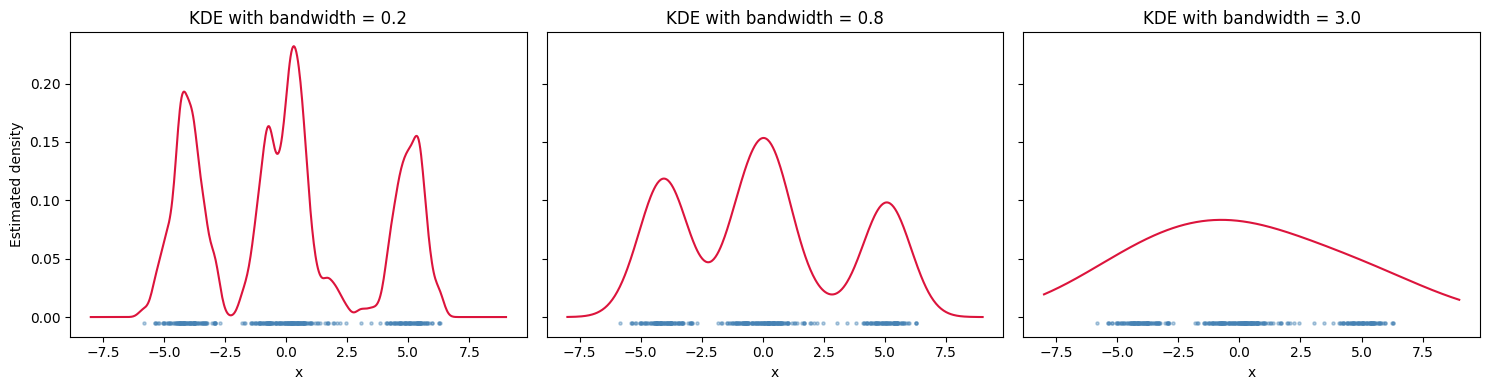

In [2]:
# 1D data drawn from three groups
data_1d = np.concatenate([
    np.random.normal(-4, 0.7, 100),
    np.random.normal(0, 0.9, 150),
    np.random.normal(5, 0.6, 80),
]).reshape(-1, 1)

x_grid = np.linspace(-8, 9, 500).reshape(-1, 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, bw in zip(axes, [0.2, 0.8, 3.0]):
    kde = KernelDensity(kernel='gaussian', bandwidth=bw).fit(data_1d)
    density = np.exp(kde.score_samples(x_grid))
    ax.plot(x_grid, density, color='crimson')
    ax.scatter(data_1d, np.full_like(data_1d, -0.005), s=5, alpha=0.4, color='steelblue')
    ax.set_title(f'KDE with bandwidth = {bw}')
    ax.set_xlabel('x')
axes[0].set_ylabel('Estimated density')
plt.tight_layout()
plt.show()


- **Small bandwidth (0.2)**: a bumpy density with many small peaks, so mean shift would find too many clusters.
- **Medium bandwidth (0.8)**: three clear peaks that match the three real groups.
- **Large bandwidth (3.0)**: peaks merge together, so mean shift would find too few clusters.

The peaks of this curve are the **modes** that mean shift discovers.


## 2. Mean Shift from Scratch (1D)

The core loop is tiny: take the mean of the points inside a window and move the window to that mean, repeating until it stops moving.


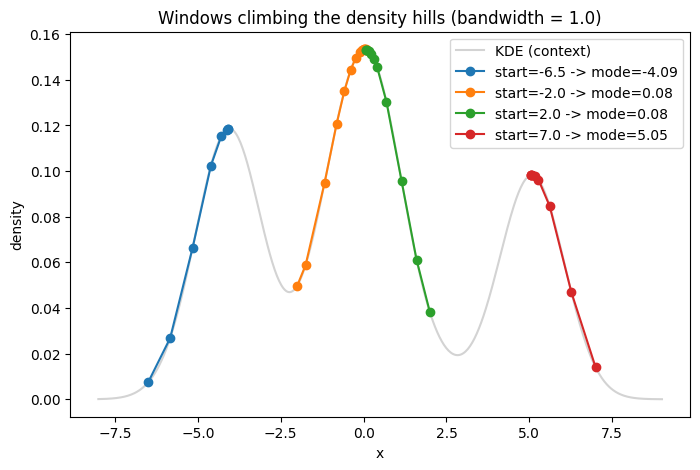

In [3]:
def mean_shift_1d_trajectory(data, start, bandwidth, max_iter=100, tol=1e-4):
    """Track how a single window moves (flat kernel)."""
    center = float(start)
    path = [center]
    for _ in range(max_iter):
        in_window = data[np.abs(data - center) <= bandwidth]
        if len(in_window) == 0:
            break
        new_center = in_window.mean()
        path.append(new_center)
        if abs(new_center - center) < tol:
            break
        center = new_center
    return path

flat_data = data_1d.ravel()
bw = 1.0
starts = [-6.5, -2.0, 2.0, 7.0]

kde = KernelDensity(kernel='gaussian', bandwidth=0.8).fit(data_1d)
density = np.exp(kde.score_samples(x_grid))

plt.plot(x_grid, density, color='lightgray', label='KDE (context)')
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
for s, c in zip(starts, colors):
    path = mean_shift_1d_trajectory(flat_data, s, bw)
    ys = np.interp(path, x_grid.ravel(), density)
    plt.plot(path, ys, 'o-', color=c, label=f'start={s} -> mode={path[-1]:.2f}')
plt.title('Windows climbing the density hills (bandwidth = 1.0)')
plt.xlabel('x')
plt.ylabel('density')
plt.legend()
plt.show()


Starting points on the left side of a hill move right toward its peak, and points on the right side move left. Windows starting near the same hill end at the same mode, which is exactly why they end up in the same cluster.


## 3. Mean Shift from Scratch (2D)

Now the full algorithm: run the shifting procedure from **every point**, then merge converged centers that are within one bandwidth of each other.


Clusters found by scratch implementation: 3


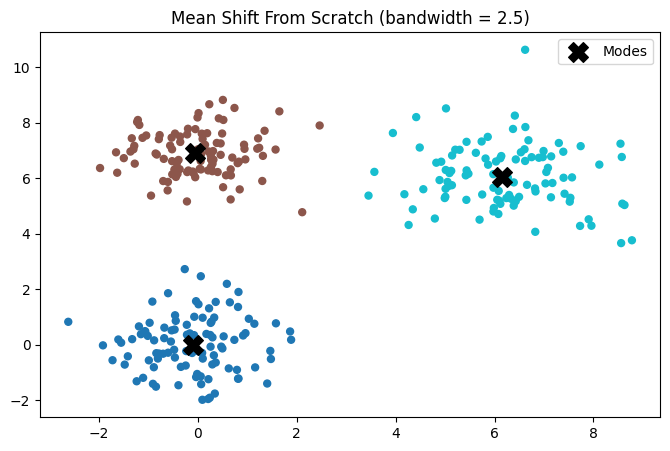

In [4]:
def mean_shift_scratch(X, bandwidth, max_iter=300, tol=1e-3):
    n = X.shape[0]
    centers = X.copy().astype(float)

    for i in range(n):
        c = centers[i]
        for _ in range(max_iter):
            dists = np.linalg.norm(X - c, axis=1)
            neighbors = X[dists <= bandwidth]
            if len(neighbors) == 0:
                break
            new_c = neighbors.mean(axis=0)
            if np.linalg.norm(new_c - c) < tol:
                c = new_c
                break
            c = new_c
        centers[i] = c

    # Merge converged centers that are within one bandwidth of each other
    unique_centers = []
    for c in centers:
        if not any(np.linalg.norm(c - u) < bandwidth for u in unique_centers):
            unique_centers.append(c)
    unique_centers = np.array(unique_centers)

    # Assign each point to its nearest final center
    dists = np.linalg.norm(X[:, None, :] - unique_centers[None, :, :], axis=2)
    labels = dists.argmin(axis=1)
    return labels, unique_centers

X, y_true = make_blobs(n_samples=300, centers=[[0, 0], [6, 6], [0, 7]], cluster_std=[1.0, 1.2, 0.8], random_state=42)

labels_scratch, centers_scratch = mean_shift_scratch(X, bandwidth=2.5)
print('Clusters found by scratch implementation:', len(centers_scratch))

plt.scatter(X[:, 0], X[:, 1], c=labels_scratch, cmap='tab10', s=25)
plt.scatter(centers_scratch[:, 0], centers_scratch[:, 1], c='black', marker='X', s=200, label='Modes')
plt.title('Mean Shift From Scratch (bandwidth = 2.5)')
plt.legend()
plt.show()


## 4. Mean Shift with Scikit-learn

The same thing in three lines with `sklearn.cluster.MeanShift`.


Number of clusters found: 3
Cluster centers:
 [[-0.06  6.89]
 [-0.09 -0.  ]
 [ 6.19  6.03]]
Iterations of the longest-running seed: 6


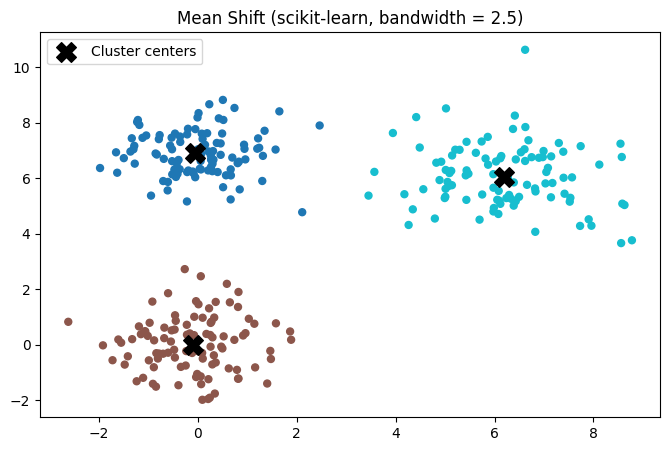

In [5]:
ms = MeanShift(bandwidth=2.5)
labels = ms.fit_predict(X)
centers = ms.cluster_centers_

print('Number of clusters found:', len(centers))
print('Cluster centers:\n', centers.round(2))
print('Iterations of the longest-running seed:', ms.n_iter_)

plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='tab10', s=25)
plt.scatter(centers[:, 0], centers[:, 1], c='black', marker='X', s=200, label='Cluster centers')
plt.title('Mean Shift (scikit-learn, bandwidth = 2.5)')
plt.legend()
plt.show()


## 5. Choosing the Bandwidth with `estimate_bandwidth`

`estimate_bandwidth` looks at the distances to nearby neighbors. The `quantile` argument controls how far it looks (between 0 and 1). A **smaller quantile** gives a **smaller bandwidth**, which gives **more clusters**.


In [6]:
for q in [0.05, 0.1, 0.2, 0.3, 0.5]:
    bw_est = estimate_bandwidth(X, quantile=q, n_samples=300)
    ms_q = MeanShift(bandwidth=bw_est, bin_seeding=True).fit(X)
    print(f'quantile={q:<4}  bandwidth={bw_est:6.2f}  clusters found={len(ms_q.cluster_centers_)}')


quantile=0.05  bandwidth=  0.85  clusters found=19
quantile=0.1   bandwidth=  1.22  clusters found=5
quantile=0.2   bandwidth=  1.83  clusters found=4
quantile=0.3   bandwidth=  2.70  clusters found=3
quantile=0.5   bandwidth=  6.32  clusters found=1


## 6. Effect of Bandwidth on the Result

Let's see visually how the same data is clustered with different window sizes.


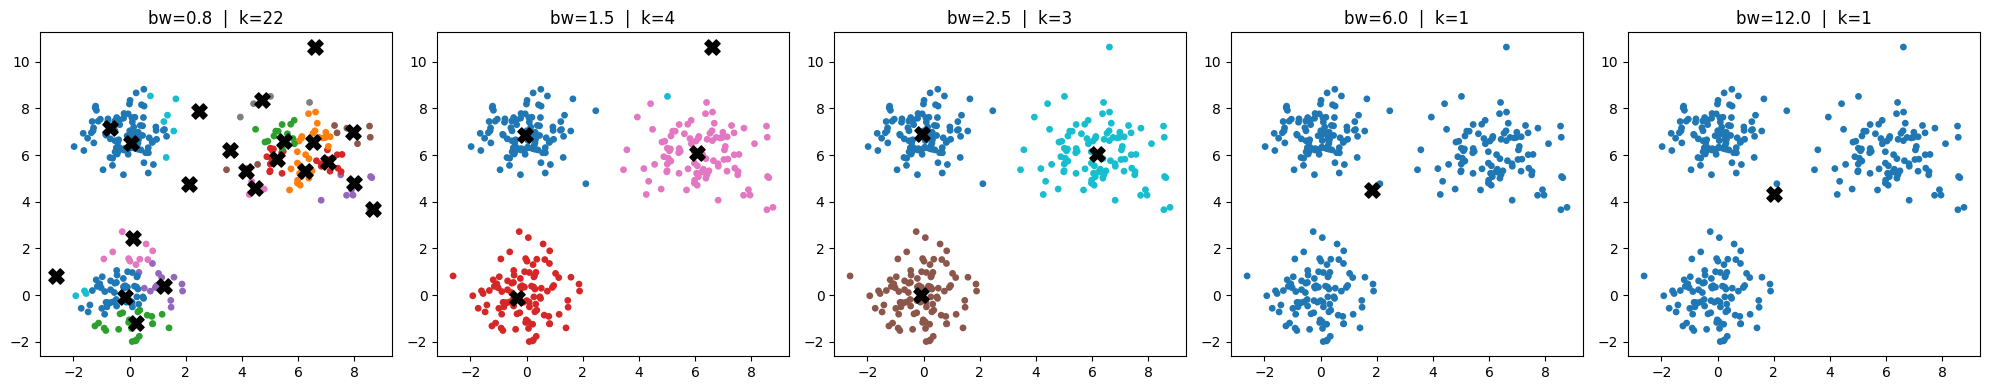

In [7]:
bandwidths = [0.8, 1.5, 2.5, 6.0, 12.0]

fig, axes = plt.subplots(1, len(bandwidths), figsize=(20, 4))
for ax, bw in zip(axes, bandwidths):
    model = MeanShift(bandwidth=bw, bin_seeding=True).fit(X)
    ax.scatter(X[:, 0], X[:, 1], c=model.labels_, cmap='tab10', s=15)
    ax.scatter(model.cluster_centers_[:, 0], model.cluster_centers_[:, 1], c='black', marker='X', s=120)
    ax.set_title(f'bw={bw}  |  k={len(model.cluster_centers_)}')
plt.tight_layout()
plt.show()


- Very small bandwidths split real clusters into many small ones.
- Very large bandwidths merge everything into one cluster.
- The middle range recovers the three true groups.

A quick way to compare candidates numerically is the **silhouette score** (only meaningful when at least 2 clusters are found):


In [8]:
for bw in [0.8, 1.5, 2.5, 4.0, 6.0]:
    model = MeanShift(bandwidth=bw, bin_seeding=True).fit(X)
    k = len(model.cluster_centers_)
    if k > 1:
        score = silhouette_score(X, model.labels_)
        print(f'bandwidth={bw:<4}  clusters={k:<3}  silhouette={score:.3f}')
    else:
        print(f'bandwidth={bw:<4}  clusters={k:<3}  silhouette=n/a')


bandwidth=0.8   clusters=22   silhouette=0.305
bandwidth=1.5   clusters=4    silhouette=0.659
bandwidth=2.5   clusters=3    silhouette=0.730
bandwidth=4.0   clusters=3    silhouette=0.730
bandwidth=6.0   clusters=1    silhouette=n/a


## 7. `bin_seeding` and `cluster_all`

- **`bin_seeding=True`** starts from grid-bin centers rather than every point, which is much faster with nearly identical results.
- **`cluster_all=False`** leaves points that are not within any seed's window unlabeled (`-1`), which works like outlier detection.


bin_seeding=False  time=0.874s  clusters=8
bin_seeding=True   time=0.090s  clusters=7


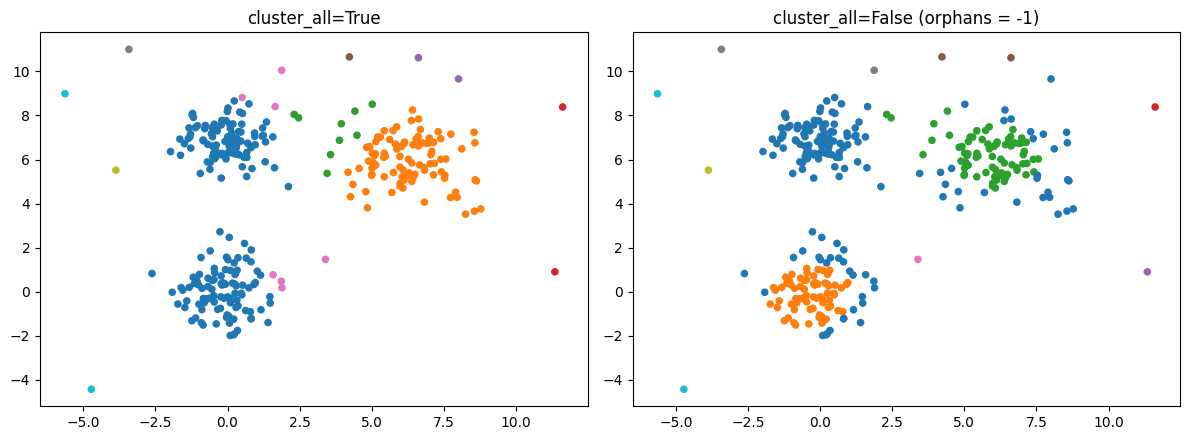

Orphan points labeled -1: 78


In [9]:
import time

# Add a few outliers
rng = np.random.RandomState(0)
outliers = rng.uniform(-6, 12, size=(15, 2))
X_out = np.vstack([X, outliers])

for seeding in [False, True]:
    t0 = time.time()
    m = MeanShift(bandwidth=2.5, bin_seeding=seeding).fit(X_out)
    print(f'bin_seeding={seeding!s:<5}  time={time.time() - t0:.3f}s  clusters={len(m.cluster_centers_)}')

m_all = MeanShift(bandwidth=1.5, cluster_all=True, bin_seeding=True).fit(X_out)
m_orphans = MeanShift(bandwidth=1.5, cluster_all=False, bin_seeding=True).fit(X_out)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, model, title in zip(axes, [m_all, m_orphans], ['cluster_all=True', 'cluster_all=False (orphans = -1)']):
    ax.scatter(X_out[:, 0], X_out[:, 1], c=model.labels_, cmap='tab10', s=20)
    ax.set_title(title)
plt.tight_layout()
plt.show()

print('Orphan points labeled -1:', int((m_orphans.labels_ == -1).sum()))


## 8. Mean Shift vs. K-Means on Non-Spherical Data

Mean shift does not need `k`, while k-means does. Here's a side-by-side on data where the number of clusters is unknown ahead of time.


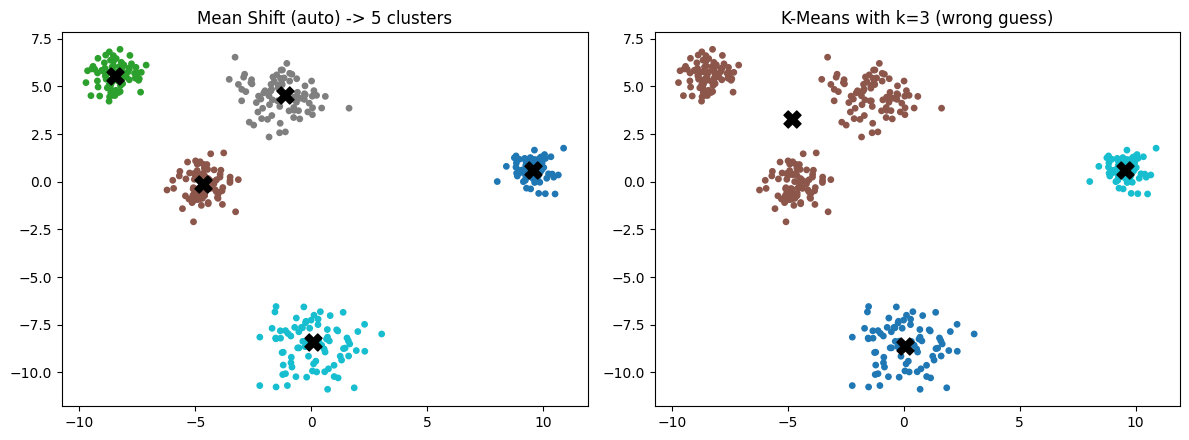

In [10]:
X2, _ = make_blobs(n_samples=400, centers=5, cluster_std=[0.6, 1.0, 0.5, 1.2, 0.7], random_state=7)

bw2 = estimate_bandwidth(X2, quantile=0.15)
ms2 = MeanShift(bandwidth=bw2, bin_seeding=True).fit(X2)
km2 = KMeans(n_clusters=3, n_init=10, random_state=0).fit(X2)   # a wrong guess for k

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(X2[:, 0], X2[:, 1], c=ms2.labels_, cmap='tab10', s=15)
axes[0].scatter(ms2.cluster_centers_[:, 0], ms2.cluster_centers_[:, 1], c='black', marker='X', s=150)
axes[0].set_title(f'Mean Shift (auto) -> {len(ms2.cluster_centers_)} clusters')

axes[1].scatter(X2[:, 0], X2[:, 1], c=km2.labels_, cmap='tab10', s=15)
axes[1].scatter(km2.cluster_centers_[:, 0], km2.cluster_centers_[:, 1], c='black', marker='X', s=150)
axes[1].set_title('K-Means with k=3 (wrong guess)')
plt.tight_layout()
plt.show()


## 9. Application: Image Color Quantization

Mean shift can group pixels by color to reduce an image to its dominant colors. We'll use a synthetic image so the notebook needs no external files.


Dominant colors found: 4


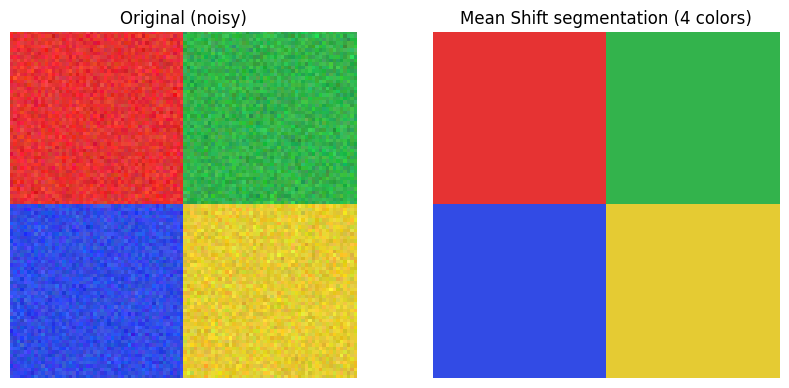

In [11]:
# Build a synthetic 100x100 "image" made of noisy color regions
rng = np.random.RandomState(1)
img = np.zeros((100, 100, 3))
img[:50, :50] = [0.9, 0.2, 0.2]    # red
img[:50, 50:] = [0.2, 0.7, 0.3]    # green
img[50:, :50] = [0.2, 0.3, 0.9]    # blue
img[50:, 50:] = [0.9, 0.8, 0.2]    # yellow
img = np.clip(img + rng.normal(0, 0.05, img.shape), 0, 1)

pixels = img.reshape(-1, 3)

bw_img = estimate_bandwidth(pixels, quantile=0.15, n_samples=500, random_state=0)
ms_img = MeanShift(bandwidth=bw_img, bin_seeding=True).fit(pixels)

segmented = ms_img.cluster_centers_[ms_img.labels_].reshape(img.shape)
print('Dominant colors found:', len(ms_img.cluster_centers_))

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
axes[0].imshow(img); axes[0].set_title('Original (noisy)'); axes[0].axis('off')
axes[1].imshow(segmented); axes[1].set_title(f'Mean Shift segmentation ({len(ms_img.cluster_centers_)} colors)'); axes[1].axis('off')
plt.show()


## 10. Summary

| Concept | Section |
|---|---|
| KDE and density peaks | 1, 2 |
| Mean shift algorithm from scratch | 2, 3 |
| `sklearn.cluster.MeanShift` | 4 |
| Bandwidth (window size) selection | 5, 6 |
| `bin_seeding`, `cluster_all` | 7 |
| Comparison with K-Means | 8 |
| Image segmentation | 9 |

For the theory behind each of these (KDE math, mean shift vector, kernels, complexity, pros and cons), see `mean_shift_theory.md`.
